In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,category_id,view_count,like_count,comment_count,duration,duration_seconds
0,0.634019,0.029288,243350.0,-0.330080,PT57S,-0.329112
1,0.017250,-0.319920,3393.0,-0.165235,PT7M50S,0.044432
2,0.634019,2.944978,4178447.0,1.003008,PT47S,-0.338157
3,0.428429,0.524317,909386.0,0.162410,PT31S,-0.352628
4,0.634019,-0.219222,44278.0,-0.138177,PT16S,-0.366195


In [3]:
# Independent variables

X = df[
    [
    "view_count",
    "comment_count",
    "duration_seconds"
    ]
]

# Target variable

y = df["like_count"]

print("Feature Head :", X.head())
print("Target Head :", y.head())

Feature Head :    view_count  comment_count  duration_seconds
0    0.029288      -0.330080         -0.329112
1   -0.319920      -0.165235          0.044432
2    2.944978       1.003008         -0.338157
3    0.524317       0.162410         -0.352628
4   -0.219222      -0.138177         -0.366195
Target Head : 0     243350.0
1       3393.0
2    4178447.0
3     909386.0
4      44278.0
Name: like_count, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 467
Testing Samples : 117


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [6]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print("Intercept :", model.intercept_)

coefficients

Intercept : 212081.84715164267


,Feature,Coefficient
0,view_count,282374.563120
1,comment_count,83791.578145
2,duration_seconds,-71179.164287


In [7]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 41770.50962299, 106911.34774576, 128761.51046035,  86768.74606466,
       104532.6455177 , 156365.71913461, 410245.37475086, 108165.9954967 ,
       123232.92496224,  87785.40777345])

In [8]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 200084.6919285506
Mean Squared Error : 210016419994.00797
Root Mean Squared Error : 458275.4848276394
R² Score : 0.5246921653011352


In [9]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,11696.000000,41770.509623
1,183.000000,106911.347746
2,20528.000000,128761.510460
3,50566.000000,86768.746065
4,18.000000,104532.645518
5,45260.000000,156365.719135
6,434811.000000,410245.374751
7,217464.608379,108165.995497
8,15665.000000,123232.924962
9,1973.000000,87785.407773


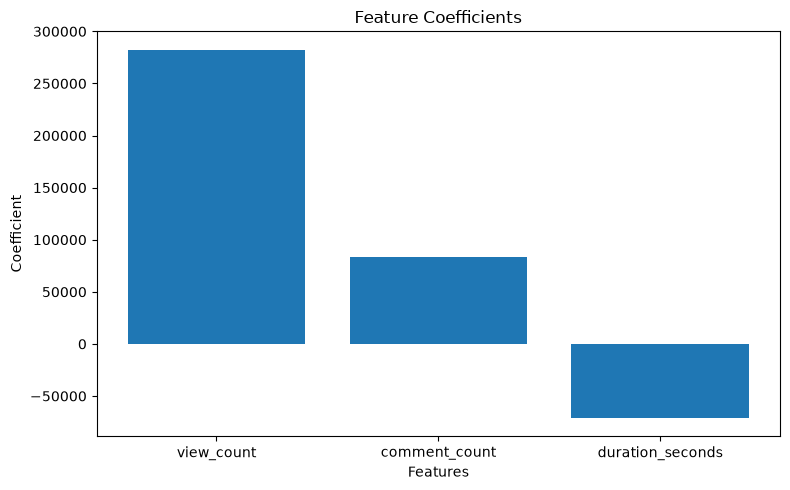

In [10]:
plt.figure(figsize=(8,5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.title("Feature Coefficients")

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.tight_layout()

plt.savefig(
    "../images/multiple_regression_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

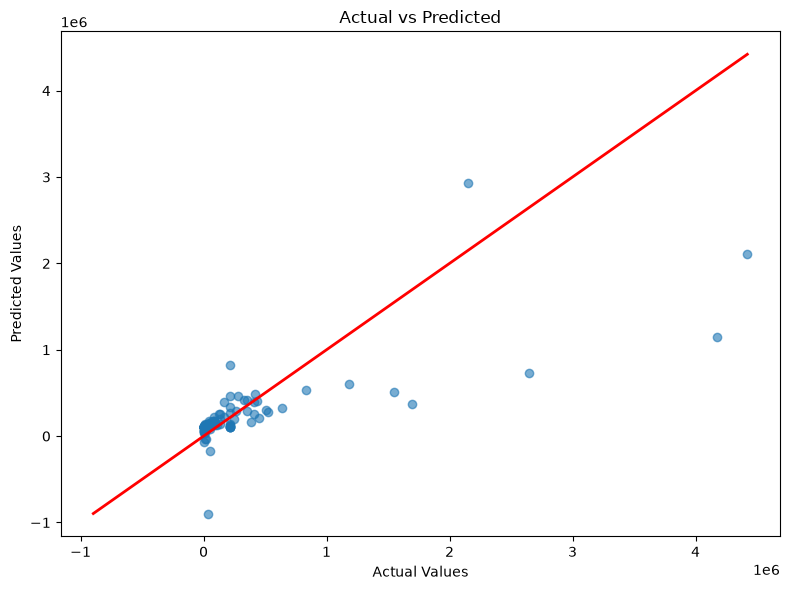

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=2
)

plt.tight_layout()

plt.savefig(
    "../images/multiple_regression_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/multiple_linear_regression.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## Conclusion

A Multiple Linear Regression model was developed using three predictor variables:

- view_count
- comment_count
- duration_seconds

### Model Performance

Mean Absolute Error : 200084.6919285506
Mean Squared Error : 210016419994.00797
Root Mean Squared Error : 458275.4848276394
R² Score : 0.5246921653011352

### Interpretation

Compared with the Simple Linear Regression model, this model demonstrates whether additional engagement-related features improve the prediction of like_count.

The coefficients also provide insight into how each feature influences the predicted number of likes.

The next notebook will explore Polynomial Regression to determine whether a non-linear relationship between view count and like count can further improve prediction accuracy.